📓 Task 2 — Sentiment & Thematic Analysis (Notebook Structure)

## Objective
This task analyzes cleaned Google Play Store reviews to extract:
- Sentiment (positive, neutral, negative)
- Key themes and keywords
- Comparative insights across Ethiopian banks

The goal is to transform raw customer feedback into actionable business insights.

## 📥 Step 1: Load Cleaned Dataset

We start by loading the preprocessed dataset from Task 1, which contains:
- Cleaned review text
- Ratings
- Bank information
- Standardized dates

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/cleaned_reviews.csv")
df.head()

,review,rating,date,bank,source
0,Good,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
1,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
2,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play
3,this app very full,5,2026-05-16,Commercial Bank of Ethiopia,Google Play
4,good apps,4,2026-05-16,Commercial Bank of Ethiopia,Google Play


## 🧠 Step 2: Sentiment Analysis

We use VADER (Valence Aware Dictionary and Sentiment Reasoner) to classify each review into:

- Positive
- Neutral
- Negative

This helps understand overall user satisfaction across banks.

In [3]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\redea\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## ⚙️ Step 3: Assign Sentiment Labels

Each review is scored using VADER compound score:

- ≥ 0.05 → Positive
- ≤ -0.05 → Negative
- Otherwise → Neutral

In [4]:
def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]
    
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

df["sentiment"] = df["review"].apply(get_sentiment)

df.head()

,review,rating,date,bank,source,sentiment
0,Good,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,positive
1,🤙🏼🤙🏼,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,neutral
2,worst,1,2026-05-16,Commercial Bank of Ethiopia,Google Play,negative
3,this app very full,5,2026-05-16,Commercial Bank of Ethiopia,Google Play,neutral
4,good apps,4,2026-05-16,Commercial Bank of Ethiopia,Google Play,positive


## 📊 Step 4: Sentiment Distribution Analysis

We now analyze the overall distribution of sentiments to understand general customer satisfaction levels.

In [5]:
df["sentiment"].value_counts()

sentiment
positive    571
neutral     270
negative    139
Name: count, dtype: int64

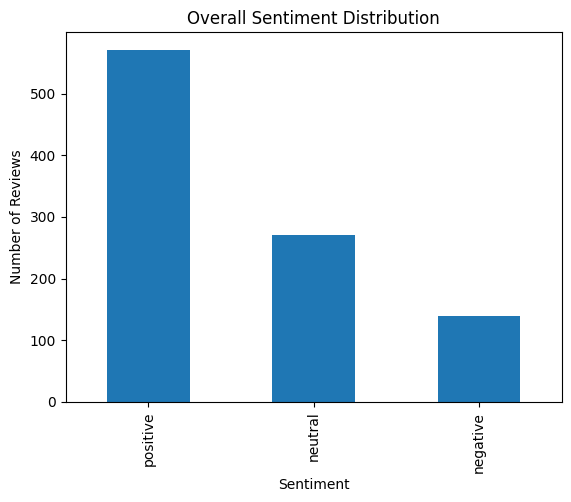

In [7]:
import matplotlib.pyplot as plt

df["sentiment"].value_counts().plot(kind="bar")
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## 🏦 Step 5: Sentiment by Bank

This analysis compares customer satisfaction across:
- CBE
- BOA
- Dashen Bank

This helps identify which bank has better or worse user experience.

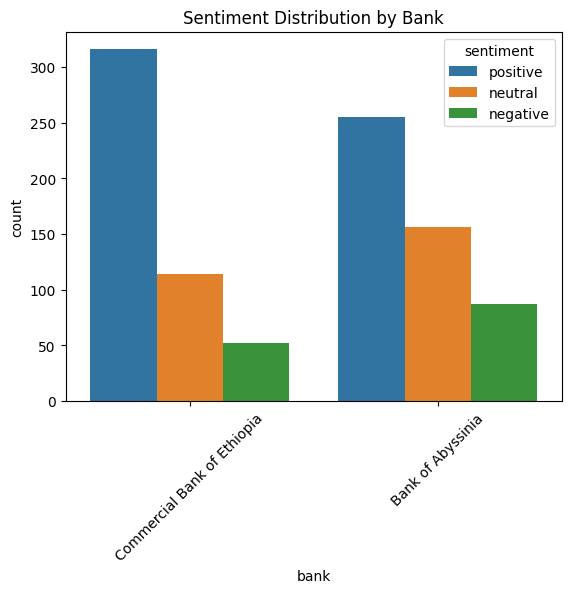

In [9]:
import seaborn as sns

sns.countplot(data=df, x="bank", hue="sentiment")
plt.title("Sentiment Distribution by Bank")
plt.xticks(rotation=45)
plt.show()

## 📉 Step 6: Validate Sentiment Against Ratings

We compare sentiment labels with actual user ratings to check consistency and model reliability.

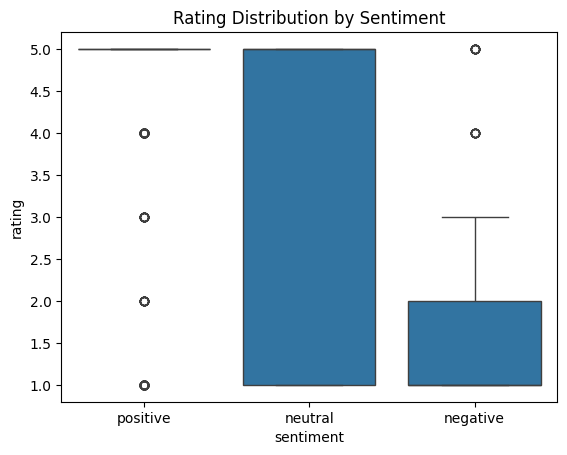

In [10]:
sns.boxplot(data=df, x="sentiment", y="rating")
plt.title("Rating Distribution by Sentiment")
plt.show()

## 🔍 Step 7: Keyword & Theme Extraction

A theme is a recurring concept in user feedback that represents a business-relevant issue such as:
- Account Access Issues
- Transaction Performance
- UI & App Experience
- Customer Support
- Feature Requests

In this section, we:
1. Extract TF-IDF keywords and bigrams (e.g., "login error", "slow transfer")
2. Identify top keywords per bank
3. Group keywords into 3–5 business themes per bank

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english",
    ngram_range=(1, 2)   # IMPORTANT: includes phrases like "login error"
)

Extract Top Keywords PER BANK

In [8]:
bank_keywords = {}

for bank in df["bank"].unique():
    subset = df[df["bank"] == bank]

    X = vectorizer.fit_transform(subset["review"].fillna("").astype(str))

    feature_names = vectorizer.get_feature_names_out()
    mean_scores = np.asarray(X.mean(axis=0)).flatten()

    keywords = sorted(
        zip(feature_names, mean_scores),
        key=lambda x: x[1],
        reverse=True
    )[:20]

    bank_keywords[bank] = keywords

## Top Keywords per Bank

The following keywords represent the most frequent and important terms extracted using TF-IDF scoring.

These keywords highlight recurring issues and user concerns specific to each bank.

In [9]:
for bank, keywords in bank_keywords.items():
    print("\n====================")
    print("BANK:", bank)
    print("====================")

    for word, score in keywords[:10]:
        print(f"{word}: {score:.4f}")


BANK: Commercial Bank of Ethiopia
good: 0.1566
app: 0.0616
nice: 0.0561
best: 0.0497
ok: 0.0373
like: 0.0189
cbe: 0.0187
nice app: 0.0171
excellent: 0.0156
working: 0.0156

BANK: Bank of Abyssinia
good: 0.1467
app: 0.0730
best: 0.0426
nice: 0.0397
boa: 0.0245
working: 0.0212
bank: 0.0188
work: 0.0157
good app: 0.0155
mobile: 0.0147


Theme Mapping (Business Logic Layer)

In [13]:
THEMES = {
    "Account Access Issues": [
        "login", "password", "sign in", "verification", "account lock"
    ],
    "Transaction Issues": [
        "transfer", "payment", "failed", "delay", "transaction"
    ],
    "UI & App Experience": [
        "app", "slow", "crash", "interface", "design"
    ],
    "Customer Support": [
        "support", "agent", "help", "response", "service"
    ],
    "Feature Requests": [
        "feature", "add", "request", "update", "missing"
    ]
}

def assign_theme(text):
    text = str(text).lower()
    scores = {theme: 0 for theme in THEMES}

    for theme, keywords in THEMES.items():
        for kw in keywords:
            if kw in text:
                scores[theme] += 1

    best_theme = max(scores, key=scores.get)

    return best_theme if scores[best_theme] > 0 else "Other"
df["identified_theme"] = df["review"].apply(assign_theme)

df[["review", "identified_theme"]].head()

,review,identified_theme
0,Good,Other
1,🤙🏼🤙🏼,Other
2,worst,Other
3,this app very full,UI & App Experience
4,good apps,UI & App Experience


Theme Distribution per Bank

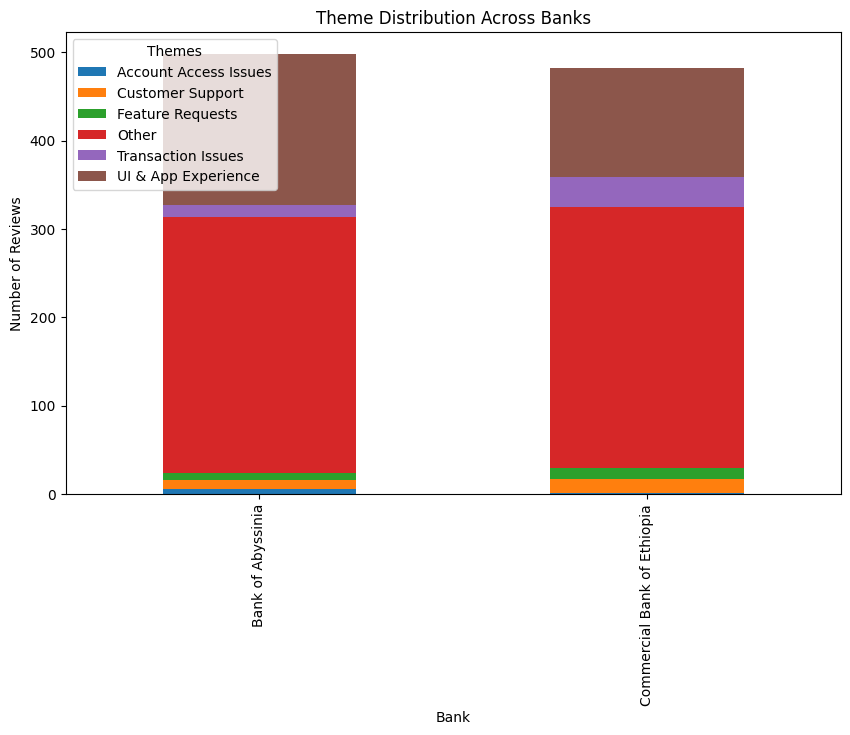

In [14]:
import matplotlib.pyplot as plt

theme_bank = pd.crosstab(df["bank"], df["identified_theme"])

theme_bank.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Theme Distribution Across Banks")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.legend(title="Themes")
plt.show()

## Thematic Analysis Interpretation

We grouped extracted TF-IDF keywords into 5 business-relevant themes:

- Account Access Issues: login and authentication problems
- Transaction Issues: failures, delays, and payment problems
- UI & App Experience: performance and usability issues
- Customer Support: service quality and responsiveness
- Feature Requests: missing or requested functionalities

Each review was assigned to the most relevant theme based on keyword matching.

This allows us to identify dominant customer pain points per bank and compare service quality across institutions.

## 📌 Step 8: Key Insights

From sentiment and theme analysis, we extract:

- Overall customer satisfaction levels
- Bank-wise performance differences
- Frequently mentioned issues
- Common feature requests

These insights will guide product improvement recommendations in the next phase.

## 💾 Step 9: Save Processed Data

We store the dataset with sentiment labels for future analysis and database integration.

In [12]:
df.to_csv("../data/raw/sentiment_reviews.csv", index=False)
print("Saved processed dataset.")

Saved processed dataset.
